In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd
path = Path("data") / "Redfin Home Price Index (RHPI)_Metro.csv"   # relative path

# Read correctly (UTF-16 + tab-delimited)
rhpi = pd.read_csv(path, sep="\t", encoding="utf-16")

# Quick sanity check
print(rhpi.shape)
print(rhpi.columns.tolist()[:10])
rhpi.head()



(8300, 5)
['Region Type', 'Month, Year of Date', 'Region Name', 'Redfin HPI MoM', 'Redfin HPI YoY']


,Region Type,"Month, Year of Date",Region Name,Redfin HPI MoM,Redfin HPI YoY
0,Metro,October 2025,"Anaheim, CA",0.50%,3.59%
1,Metro,October 2025,"Atlanta, GA",0.34%,1.00%
2,Metro,October 2025,"Austin, TX",0.71%,-3.38%
3,Metro,October 2025,"Baltimore, MD",0.66%,3.87%
4,Metro,October 2025,"Boston, MA",0.59%,4.73%


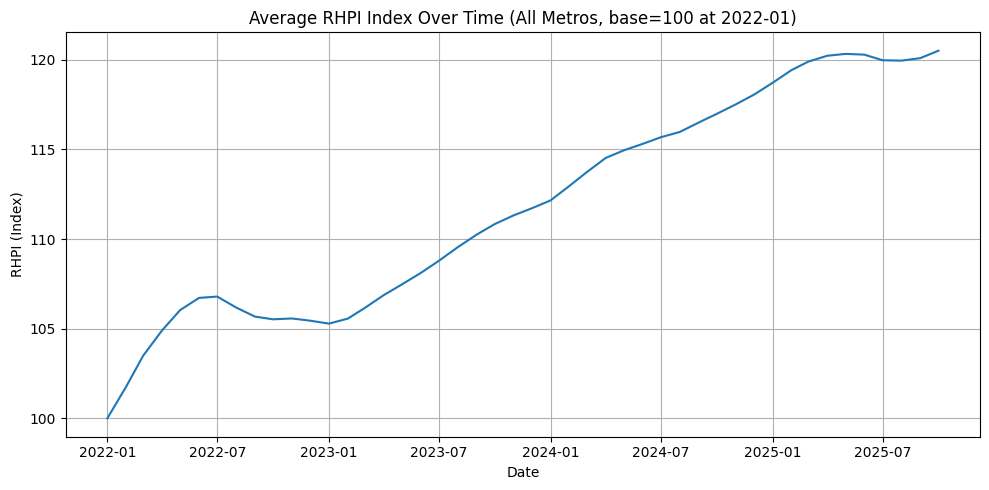

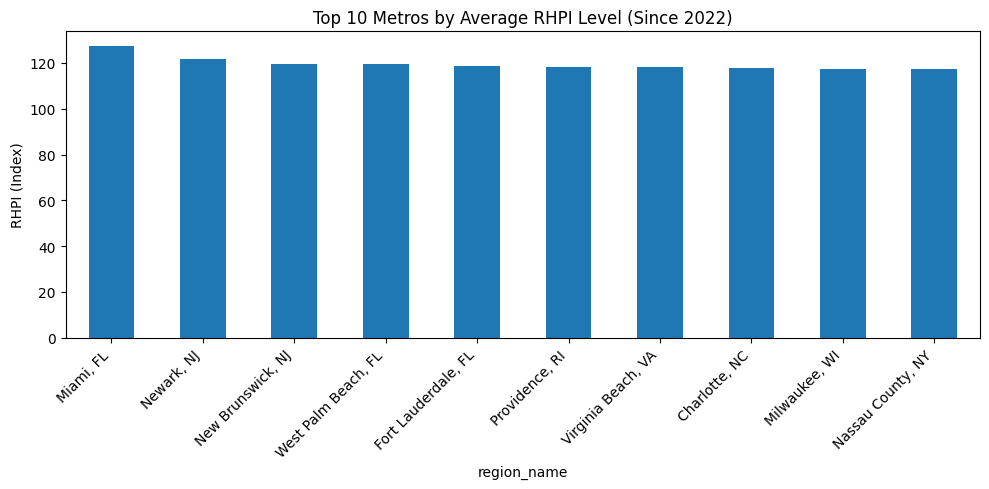

Correlation between RHPI MoM and YoY: 0.435


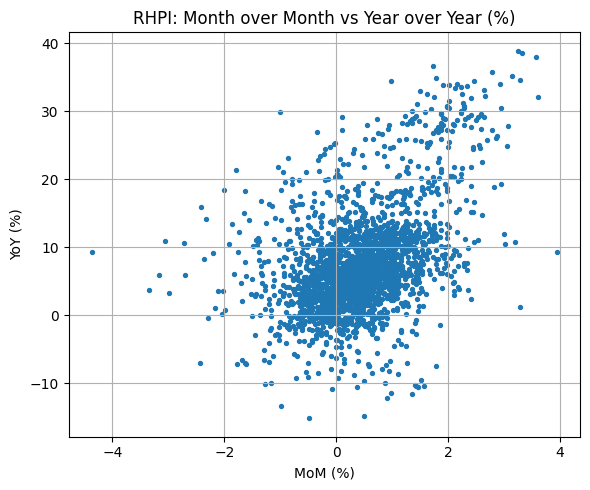

In [9]:
import numpy as np
import pandas as pd

# make sure MoM / YoY are numeric
for col in ["redfin_hpi_mom", "redfin_hpi_yoy"]:
    rhpi[col] = (
        rhpi[col]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    rhpi[col] = pd.to_numeric(rhpi[col], errors="coerce")

# (re)filter recent + sort
rhpi_recent = rhpi[(rhpi["date"] >= "2022-01-01") & rhpi["region_type"].str.contains("metro", case=False, na=False)].copy()
rhpi_recent["region_name"] = rhpi_recent["region_name"].str.replace(r"\s*metro area$", "", regex=True).str.strip()
rhpi_recent = rhpi_recent.sort_values(["region_name", "date"])

# Treat missing MoM as 0% for the cumprod step 
rhpi_recent["mom_factor"] = 1.0 + rhpi_recent["redfin_hpi_mom"].fillna(0) / 100.0

def base100(series: pd.Series) -> pd.Series:
    """Return a base-100 index from a series of multiplicative factors."""
    cp = series.cumprod()
    # normalize by the first *valid* value so the first valid month = 100
    first_idx = series.first_valid_index()
    if first_idx is None:
        return pd.Series(np.nan, index=series.index)
    base = cp.loc[first_idx]
    return (cp / base) * 100.0

rhpi_recent["rhpi_index"] = rhpi_recent.groupby("region_name")["mom_factor"].transform(base100)

# Convert to factor (1 + MoM/100), cumprod per region, base = 100.
rhpi_recent = rhpi_recent.sort_values(["region_name", "date"])
rhpi_recent["mom_factor"] = 1 + (rhpi_recent["redfin_hpi_mom"] / 100.0)

# Start each region at 100 on its first month in the filtered period
rhpi_recent["rhpi_index"] = (
    rhpi_recent.groupby("region_name")["mom_factor"]
    .apply(lambda s: s.cumprod() / s.iloc[0] * 100.0)
    .values
)

# Price Trend Over Time (RHPI)

avg_index = rhpi_recent.groupby("date")["rhpi_index"].mean()

plt.figure(figsize=(10,5))
plt.plot(avg_index.index, avg_index.values)
plt.title("Average RHPI Index Over Time (All Metros, base=100 at 2022-01)")
plt.xlabel("Date")
plt.ylabel("RHPI (Index)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Top 10 Metro Areas by RHPI Level (Since 2022)
top10 = (
    rhpi_recent.groupby("region_name")["rhpi_index"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top10.plot(kind="bar")
plt.title("Top 10 Metros by Average RHPI Level (Since 2022)")
plt.ylabel("RHPI (Index)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 5) MoM vs YoY relationship (simple correlation/plot)
subset = rhpi_recent[["redfin_hpi_mom", "redfin_hpi_yoy"]].dropna()
corr_val = subset.corr().loc["redfin_hpi_mom", "redfin_hpi_yoy"]
print(f"Correlation between RHPI MoM and YoY: {corr_val:.3f}")

plt.figure(figsize=(6,5))
plt.scatter(subset["redfin_hpi_mom"], subset["redfin_hpi_yoy"], s=8)
plt.title("RHPI: Month over Month vs Year over Year (%)")
plt.xlabel("MoM (%)")
plt.ylabel("YoY (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_9748\2408673446.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  redfin["date"] = pd.to_datetime(redfin["month,_year_of_date"], errors="coerce")
C:\Users\User\AppData\Local\Temp\ipykernel_9748\2408673446.py:16: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  redfin_jul_aug = redfin[redfin["date"].isin(["2025-07-01", "2025-08-01"])][
C:\Users\User\AppData\Local\Temp\ipykernel_9748\2408673446.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  zillow_long["date"] 

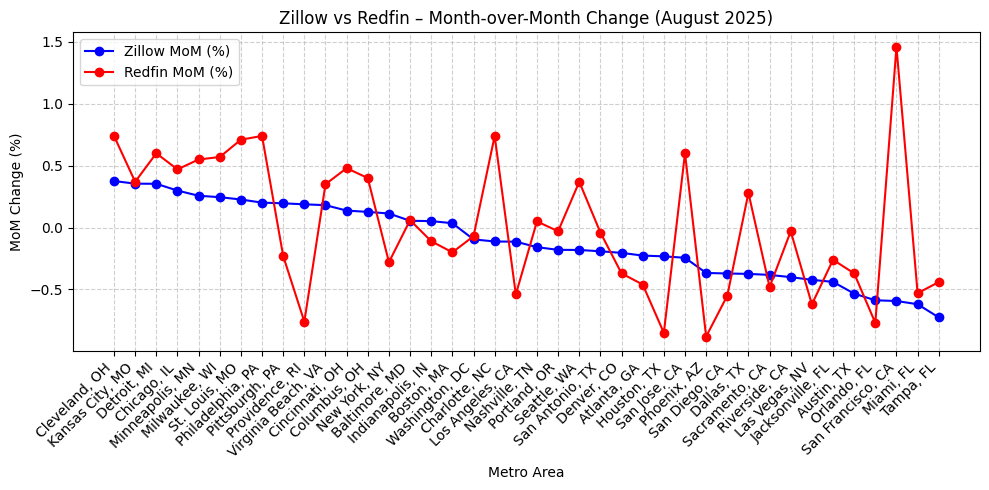

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Read data
redfin = pd.read_csv("data/Redfin Home Price Index (RHPI)_Metro.csv",
                     sep="\t", encoding="utf-16")
zillow = pd.read_csv("data/Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv")

# Clean Redfin RHPI
redfin.columns = redfin.columns.str.strip().str.lower().str.replace(" ", "_")
redfin["date"] = pd.to_datetime(redfin["month,_year_of_date"], errors="coerce")
redfin["region_name"] = redfin["region_name"].str.replace(r"\s*metro area$", "", regex=True).str.strip()
redfin["redfin_hpi_mom"] = redfin["redfin_hpi_mom"].str.replace("%", "").astype(float)

# Filter July and August 2025
redfin_jul_aug = redfin[redfin["date"].isin(["2025-07-01", "2025-08-01"])][
    ["region_name", "date", "redfin_hpi_mom"]
]

# Clean Zillow ZHVI
zillow = zillow.rename(columns={"RegionName": "region_name"})
zillow_long = zillow.melt(id_vars=["region_name"], var_name="date", value_name="zhvi")
zillow_long["date"] = pd.to_datetime(zillow_long["date"], errors="coerce")

# Compute Zillow MoM change from July to August 2025
zillow_2025 = zillow_long[zillow_long["date"].isin(["2025-07-31", "2025-08-31"])].copy()
zillow_2025 = zillow_2025.sort_values(["region_name", "date"])

# Calculate MoM percent change per metro
zillow_2025["zhvi_mom"] = zillow_2025.groupby("region_name")["zhvi"].pct_change() * 100
zillow_mom = zillow_2025[zillow_2025["date"] == "2025-08-31"][["region_name", "zhvi_mom"]]

# Merge Redfin + Zillow MoM
redfin_aug25 = redfin[redfin["date"] == "2025-08-01"][["region_name", "redfin_hpi_mom"]]
compare = pd.merge(redfin_aug25, zillow_mom, on="region_name", how="inner")

# Sort by Zillow MoM
compare = compare.sort_values("zhvi_mom", ascending=False)

# Plot both as line charts
plt.figure(figsize=(10, 5))
plt.plot(compare["region_name"], compare["zhvi_mom"], marker="o", label="Zillow MoM (%)", color="blue")
plt.plot(compare["region_name"], compare["redfin_hpi_mom"], marker="o", label="Redfin MoM (%)", color="red")

plt.title("Zillow vs Redfin – Month-over-Month Change (August 2025)")
plt.xlabel("Metro Area")
plt.ylabel("MoM Change (%)")
plt.xticks(rotation=45, ha="right")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_9748\914720902.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  redfin["date"] = pd.to_datetime(redfin["month,_year_of_date"], errors="coerce")
C:\Users\User\AppData\Local\Temp\ipykernel_9748\914720902.py:31: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  zl["date"] = pd.to_datetime(zl["date"], errors="coerce")


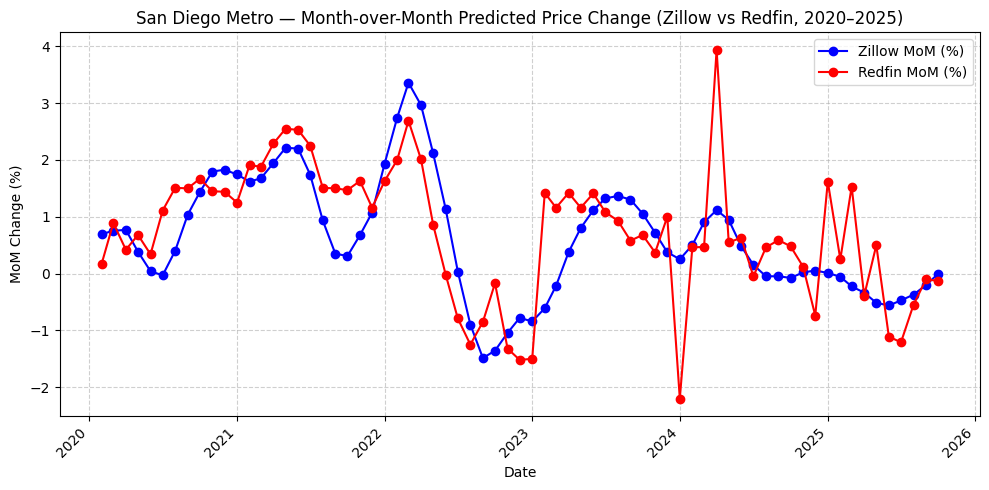

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Read data
redfin = pd.read_csv("data/Redfin Home Price Index (RHPI)_Metro.csv",
                     sep="\t", encoding="utf-16")
zillow = pd.read_csv("data/Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv")

# Clean Redfin
redfin.columns = redfin.columns.str.strip().str.lower().str.replace(" ", "_")
redfin["date"] = pd.to_datetime(redfin["month,_year_of_date"], errors="coerce")
redfin["region_name"] = redfin["region_name"].str.replace(r"\s*metro area$", "", regex=True).str.strip()
redfin["redfin_hpi_mom"] = (
    redfin["redfin_hpi_mom"].astype(str)
    .str.replace("%", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
redfin["redfin_hpi_mom"] = pd.to_numeric(redfin["redfin_hpi_mom"], errors="coerce")

# Filter for San Diego and year range 2020–2025
sd_redfin = redfin[
    (redfin["region_name"].str.contains("San Diego", case=False)) &
    (redfin["date"].dt.year.between(2020, 2025))
][["date", "redfin_hpi_mom"]]
sd_redfin["month"] = sd_redfin["date"].dt.to_period("M")

# Clean Zillow
zillow = zillow.rename(columns={"RegionName": "region_name"})
zl = zillow.melt(id_vars=["region_name"], var_name="date", value_name="zhvi")
zl["date"] = pd.to_datetime(zl["date"], errors="coerce")
zl["zhvi"] = pd.to_numeric(zl["zhvi"], errors="coerce")

# Filter for San Diego and 2020–2025
sd_zillow = zl[
    (zl["region_name"].str.contains("San Diego", case=False)) &
    (zl["date"].dt.year.between(2020, 2025))
].copy()
sd_zillow = sd_zillow.sort_values("date")
sd_zillow["zillow_mom_pct"] = sd_zillow["zhvi"].pct_change() * 100
sd_zillow["month"] = sd_zillow["date"].dt.to_period("M")

# Merge by month
sd = pd.merge(sd_zillow[["month", "zillow_mom_pct"]],
              sd_redfin[["month", "redfin_hpi_mom"]],
              on="month", how="inner").dropna()

# Plot
plt.figure(figsize=(10,5))
plt.plot(sd["month"].dt.to_timestamp(), sd["zillow_mom_pct"], marker="o", label="Zillow MoM (%)", color="blue")
plt.plot(sd["month"].dt.to_timestamp(), sd["redfin_hpi_mom"], marker="o", label="Redfin MoM (%)", color="red")

plt.title("San Diego Metro — Month-over-Month Predicted Price Change (Zillow vs Redfin, 2020–2025)")
plt.xlabel("Date")
plt.ylabel("MoM Change (%)")
plt.xticks(rotation=45, ha="right")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()
